In [2]:
import csv
import random
from ClasesAux import *
from random import *


In [2]:
def infoExtract(cartasCsv,personajesCsv,rolesCsv):
    baraja = list()
    with open(cartasCsv, newline='') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=';')
        idObjetc = 0
        for row in spamreader:
            idClase = int(row[0])
            nombre = row[1]
            tipo = row[2]
            for i in range(int(row[3])):
                carta = Carta(idObjetc,idClase, nombre,tipo)
                baraja.append(carta)
                idObjetc = idObjetc + 1
                
        #lista = list(range(0,len(baraja)))
        random.shuffle(baraja)

    personajes = list()
    with open(personajesCsv, newline='') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=';')
        for row in spamreader:
            idPersonaje = int(row[0])
            nombre = row[1]
            vidas = int(row[2])
            personaje = Personaje(idPersonaje,nombre,vidas)
            personajes.append(personaje)
            
            
    roles = list()
    with open(rolesCsv, newline='') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=';')
        for row in spamreader:
            rol = row[0]
            roles.append(rol)

            
    return baraja,personajes,roles



In [3]:
inicio = infoExtract("cartas.csv","personajes.txt","roles.txt")
cartas = inicio[0]
personajes = inicio[1]
roles = inicio[2]

print("BIENVENIDO AL ANTIGUO OESTE") 
print("Esto es el juego BANG")

numJugadores = input("¿CUANTOS JUGADORES SOIS? ") 
listaNicks = list() 
listaJugadores = list()

if (int(numJugadores) ==4 or int(numJugadores) ==5 or int(numJugadores) ==6 or int(numJugadores) ==7): 
    print("Modo de juego para "+ numJugadores +" jugadores") 
    for i in range(int(numJugadores)): 
        username = input("Jugador "+ str(i+1)+":") 
        listaNicks.append(username)

    lista = list(range(0,14))
    listaRol = list(range(0,int(numJugadores)))

    random.shuffle(lista)
    random.shuffle(listaRol)
    idJugador = 0
    for p in listaNicks:
        a = lista.pop()
        b = lista.pop()
        personaje =""
        rol=str(roles[listaRol.pop()])
        personajeLetra = input("Jugador "+ str(p)+"eres "+ rol +" que personaje prefieres A: "+ str(personajes[a].nombre) +" o B:" + str(personajes[b].nombre))
        if personajeLetra == "A" or personajeLetra == "a":
            personaje = personajes[a]

        elif personajeLetra == "B" or personajeLetra == "b":
            personaje = personajes[b]

        else:
            print("CHUPAME LA POLLA")

        jugador = Jugador(idJugador,str(p),personaje,rol,[])
        listaJugadores.append(jugador)
        idJugador = idJugador + 1
        print(jugador)
else: print("Solo existen los modos 4,5,6,7 jugadores :)")


BIENVENIDO AL ANTIGUO OESTE
Esto es el juego BANG
¿CUANTOS JUGADORES SOIS? 4
Modo de juego para 4 jugadores
Jugador 1:1
Jugador 2:2
Jugador 3:3
Jugador 4:4
Jugador 1eres Forajido que personaje prefieres A: Jourdonnais o B:Calamity Janeta
-----------------
-IdJugador: 0
-Nombre: 1
-Rol:Forajido 
-Personaje: Jourdonnais
-Vidas: 4
-----------------
 CARTAS EN MANO: 

Jugador 2eres Sheriff que personaje prefieres A: Sid Ketchum o B:El Gringoa
-----------------
-IdJugador: 1
-Nombre: 2
-Rol:Sheriff 
-Personaje: Sid Ketchum
-Vidas: 4
-----------------
 CARTAS EN MANO: 

Jugador 3eres Renegado que personaje prefieres A: Jesse Jones o B:Kit Carlsona
-----------------
-IdJugador: 2
-Nombre: 3
-Rol:Renegado 
-Personaje: Jesse Jones
-Vidas: 4
-----------------
 CARTAS EN MANO: 

Jugador 4eres Forajido que personaje prefieres A: Paul Regret o B:Black Jacka
-----------------
-IdJugador: 3
-Nombre: 4
-Rol:Forajido 
-Personaje: Paul Regret
-Vidas: 3
-----------------
 CARTAS EN MANO: 



In [ ]:
class Juego():
    
    def __init__(self,jugadores,baraja):
        print(len(jugadores[0].cartasMano))
        inicio = self.repartirCartasInicio(jugadores,baraja)
        print(len(inicio[0][0].cartasMano))

        self.jugadores = inicio[0]
        self.baraja =inicio[1]
        self.ronda = 0
        self.turno = 0 
        self.jugadoresEliminados = []
        self.montonDescartes = []
        
    def __str__(self):
        datos = "DATOS DE LA PARTIDA\n-RONDA Nº "+str(self.ronda)+"\n-TURNO Nº" + str(self.turno)
        jugadoresStr = "\n -------------------------------------\n JUGADORES \n" 
        for j in self.jugadores:
            jugadoresStr = jugadoresStr + j.__str__()
        return datos + jugadoresStr
    
    def repartirCartasInicio(self,jugadores,baraja):
        for j in range(len(jugadores)):
            carta1 = baraja.pop()
            carta2 = baraja.pop()
            carta3 = baraja.pop()
            carta4 = baraja.pop()
            carta5 = baraja.pop()
            jugadores[j].cartasMano.append(carta1)
            jugadores[j].cartasMano.append(carta2)
            jugadores[j].cartasMano.append(carta3)
            jugadores[j].cartasMano.append(carta4)
            jugadores[j].cartasMano.append(carta5)
        return jugadores,baraja
    
    
    def barajarMonton(self):
        self.baraja = random.shuffle(montonDescartes)
        self.montonDescartes = []
    
    def echarCartas(self):
        print(randint(0, 30))

    def recibeCarta(self,idJugador):
        if len(self.baraja) == 0:
            self.barajarMonton()
        carta = self.baraja.pop()
        jugador = self.jugadores[idJugador]
        jugador.recibeCarta(carta)
        self.jugadores[idJugador] = jugador
        
    def perderCarta(self,idJugador,idCarta):
        carta = self.jugadores[idJugador].getCarta(idCarta)
        self.jugadores[idJugador].pierdeCarta(idCarta)
        self.montonDescartes.append(carta)
    
    def elegirRival(self,idJugador):
        rivales = "¿Quien es tu rival?"
        for j in self.jugadores:
            if not j.idJugador == j:
                rivales = rivales + "\n"+str(j.idJugador)+" - " + j.nombre
        print(rivales)
        idRival = -1
        posiblesRivales = list(range(len(self.jugadores)))
        while(not(int(idRival) in posiblesRivales)):
            try:
                idRival = input("\n Escribe el número del rival")
                idRival = int(idRival)-1

            except:
                print("ESCRIBA UN NUMERO DENTRO DE LAS POSIBILIDADES")
        return idRival
    
    def respuesta(self,idRival,idCarta):
        rival = self.jugadores[idRival]
        if idCarta == 11 or idCarta == 14 or idCarta == 15 or idCarta == 16:
            if idCarta == 11:
                respuesta = input("\n Te han hecho un BANG. Quieres usar un FALLASTE? \n SI o NO?")
                idCartaRespuesta = 12
            if idCarta == 14:
                respuesta = input("\n Han hecho un INDIOS. Quieres usar un BANG? \n SI o NO?")
                idCartaRespuesta = 11
            if idCarta == 15:
                respuesta = input("\n Te han hecho un DUELO. Quieres usar un BANG? \n SI o NO?")
                idCartaRespuesta = 11
            if idCarta == 16:
                respuesta = input("\n Te han hecho un AMETRALLADORA. Quieres usar un FALLASTE? \n SI o NO?")
                idCartaRespuesta = 12
            booleanCarta,idMano = self.tenerCarta(rival,idCartaRespuesta)
            if respuesta == "SI" and booleanCarta:
                self.fallaste_descartarBang(idRival,idMano)
                return True
            else:
                return False
            
    def tenerCarta(self,jugador,idCarta):
        res = False
        i = 0
        for carta in jugador.cartasMano:
            if carta.idClase == idCarta:
                res = True
        return res,i
    
    def fallaste_descartarBang(self,idJugador,idCarta):
        self.perderCarta(idJugador,idCarta)
            
    def anadirArma(self,idJugador,idCarta):
        carta = self.jugadores[idJugador].getCarta(idCarta)
        arma = carta.idClase
        if(not self.jugadores[idJugador].arma == 0):
            print("YA TIENES UN ARMA")
            self.jugadores[idJugador].cambioArma(arma,1)
        else:
            print("HAS CAMBIADO DE ARMA")
            self.jugadores[idJugador].cambioArma(arma,1)
        self.perderCarta(idJugador,idCarta)

    
    
    def carcel(self,idJugador,idEnemigo,idCarta):
        if(not self.jugadores[idEnemigo].carcel):
            self.jugadores[idEnemigo].ponerCarcel()
            self.perderCarta(idJugador,idCarta)
            print("HAS PUESTO UNA CARCEL A")
        else:
            print("NO PUEDES PONER MAS CARCELES A ESTE JUGADOR")
    
    def bang(self,idJugador,idEnemigo,idCarta):
        if(self.jugadores[idJugador].contBang == 0  or self.jugadores[idJugador].volcanic):
            print("HAS DISPARADO A")
            print(self.jugadores[idEnemigo].__str__())
            self.perderCarta(idJugador,idCarta)
            self.jugadores[idJugador].contBang = self.jugadores[idJugador].contBang + 1
            respuesta = self.respuesta(idEnemigo,11)
            if not respuesta:
                self.jugadores[idEnemigo].perderVida()
            else:
                print("¡PERO HAS FALLADO!")
        else:
            print("NO PUEDES HACER MAS BANGS")
    
    def ametralladora(self,idJugador,idCarta):
        print("HAS REALIZADO UNA AMETRALLADORA GATLING")
        print("HAS DISPARADO A")
        self.perderCarta(idJugador,idCarta)
        for idEnemigo in range(self.jugadores)
            if (idJugador != idEnemigo):
                print(self.jugadores[idEnemigo].__str__())
                respuesta = self.respuesta(idEnemigo,11)
                if not respuesta:
                    self.jugadores[idEnemigo].perderVida()
                else:
                    print("¡PERO HAS FALLADO!")
                    
    def indios(self,idJugador,idCarta):
        print("HAS REALIZADO UNOS INDIOS")
        print("¡LANZA UN BANG!")
        self.perderCarta(idJugador,idCarta)
        for idEnemigo in range(self.jugadores)
            if (idJugador != idEnemigo):
                print(self.jugadores[idEnemigo].__str__())
                respuesta = self.respuesta(idEnemigo,11)
                if not respuesta:
                    self.jugadores[idEnemigo].perderVida()
                else:
                    print("¡PERO HAS FALLADO!")
    
    def cerveza(self,idJugador,idCarta):
        if(self.jugadores[idJugador].vidas >= self.jugadores[idJugador].vidasMax):
            print("NO PUEDES USARLA TIENES MAXIMO DE VIDA")
        else:
            self.jugadores[idJugador].ganarVida()
            self.perderCarta(idJugador,idCarta)
            print("TE HAS TOMADO UNA CERVEZA")
            
            
    def mustang(self,idJugador,idCarta):
        if(self.jugadores[idJugador].mustang):
            print("YA TIENES UN MUSTANG")
        else:
            self.jugadores[idJugador].ponerMustang()
            self.perderCarta(idJugador,idCarta)
            print("TE HAS PUESTO UN MUSTANG")

            
    def barril(self,idJugador,idCarta):
        if(self.jugadores[idJugador].barril):
            print("YA TIENES UN BARRIL")
        else:
            self.jugadores[idJugador].ponerBarril()
            self.perderCarta(idJugador,idCarta)
            print("TE HAS PUESTO UN BARRIL")
            
    def miraTelescopica(self,idJugador,idCarta):
        if(self.jugadores[idJugador].miraTelescopica):
            print("YA TIENES UNA MIRA TELESCOPICA")
        else:
            self.jugadores[idJugador].ponerMiraTelescopica()
            self.perderCarta(idJugador,idCarta)
            print("TE HAS PUESTO UNA MIRA TELESCOPICA")
            
    def diligencia(self,idJugador,idCarta):
        jugador = self.jugadores[idJugador]
        carta = self.baraja.pop()
        jugador.recibeCarta(carta)
        carta = self.baraja.pop()
        jugador.recibeCarta(carta)
        self.jugadores[idJugador] = jugador
        self.perderCarta(idJugador,idCarta)

        
    def wellsFargo(self,idJugador,idCarta):
        jugador = self.jugadores[idJugador]
        carta = self.baraja.pop()
        jugador.recibeCarta(carta)
        carta = self.baraja.pop()
        jugador.recibeCarta(carta)
        carta = self.baraja.pop()
        jugador.recibeCarta(carta)
        self.jugadores[idJugador] = jugador
        self.perderCarta(idJugador,idCarta)
        

            
    def turnoJugador(self,idJugador):
        if (not self.jugadores[idJugador].muerto):
            self.jugadores[idJugador].contBang = 0
            print("TURNO DE: \n")
            self.recibeCarta(idJugador)
            self.recibeCarta(idJugador)
            print(self.jugadores[idJugador].__str__())
            idCarta = -1
            booleanFin = True
            while(idCarta !="FIN" and booleanFin):
                idCarta = input("¿Quieres usar una carta? Escribe el número o FIN ")
                posiblesCartas = list(range(len(self.jugadores[idJugador].cartasMano)))
                if idCarta == "FIN":
                    booleanFin = False 
                    while len(self.jugadores[idJugador].cartasMano) > self.jugadores[idJugador].vidas:
                        idCarta = input("TIENES QUE DESCARTAR UNA CARTA. Escribe el número")
                        try:
                            print(idCarta)
                            idCarta = int(idCarta)-1
                            if int(idCarta) in posiblesCartas:
                                self.perderCarta(idJugador, int(idCarta))
                            else:
                                print("ESCRIBA UN NUMERO DENTRO DE LAS POSIBILIDADES")

                        except:
                            print("ESCRIBA UN NUMERO")

                    print("HAS TERMINADO TU TURNO")    
                else :
                    try:
                        print(idCarta)
                        idCarta = int(idCarta)-1
                        if int(idCarta) in posiblesCartas:
                            claseCarta = self.jugadores[idJugador].getCarta(int(idCarta)).idClase
                            if (claseCarta == 1) or (claseCarta == 2) or (claseCarta == 3) or (claseCarta == 4) or (claseCarta == 5):
                                #PROBAR
                                self.anadirArma(idJugador, int(idCarta))
                            if claseCarta == 6:
                                idEnemigo = self.elegirRival(idJugador)
                                self.carcel(idJugador,idEnemigo,int(idCarta))
                            if claseCarta == 7:
                                self.mustang(idJugador, int(idCarta))
                            if claseCarta == 8:
                                self.barril(idJugador, int(idCarta))
                            if claseCarta == 10:
                                self.miraTelescopica(idJugador, int(idCarta))
                            if claseCarta == 11:
                                idEnemigo = self.elegirRival(idJugador)
                                self.bang(idJugador,idEnemigo,int(idCarta))
                            if claseCarta == 13:
                                self.cerveza(idJugador, int(idCarta))
                            if claseCarta == 14:
                                #PROBAR
                                self.indios(idJugador,int(idCarta))
                            if claseCarta == 16:
                                #PROBAR
                                self.ametralladora(idJugador,int(idCarta))
                            if claseCarta == 21:
                                self.diligencia(idJugador, int(idCarta))
                            if claseCarta == 22:
                                self.wellsFargo(idJugador, int(idCarta))
                    except:
                        print("ESCRIBA UN NUMERO O FIN")
                
    def partida(self):
        while(len(self.jugadores)>1):
            if self.turno > len(self.jugadores):
                self.turno = 0
                self.ronda = self.ronda + 1
            self.turnoJugador(self.turno)    
            self.turno = self.turno + 1
            

        

In [5]:
a = Juego(listaJugadores,cartas)


0
5


In [6]:
print(a)

DATOS DE LA PARTIDA
-RONDA Nº 0
-TURNO Nº0
 -------------------------------------
 JUGADORES 
-----------------
-IdJugador: 0
-Nombre: 1
-Rol:Forajido 
-Personaje: Jourdonnais
-Vidas: 4
-----------------
 CARTAS EN MANO: 
-----------------
-Nombre: Fallaste

----------------------------------
-Nombre: Fallaste

----------------------------------
-Nombre: Indios

----------------------------------
-Nombre: Bang

----------------------------------
-Nombre: Almacen

----------------------------------
-IdJugador: 1
-Nombre: 2
-Rol:Sheriff 
-Personaje: Sid Ketchum
-Vidas: 4
-----------------
 CARTAS EN MANO: 
-----------------
-Nombre: Cerveza

----------------------------------
-Nombre: Diligencia

----------------------------------
-Nombre: Bang

----------------------------------
-Nombre: Panico

----------------------------------
-Nombre: Bang

----------------------------------
-IdJugador: 2
-Nombre: 3
-Rol:Renegado 
-Personaje: Jesse Jones
-Vidas: 4
-----------------
 CARTAS EN MANO: 

In [ ]:
a.partida()

TURNO DE: 

-----------------
-IdJugador: 0
-Nombre: 1
-Rol:Forajido 
-Personaje: Jourdonnais
-Vidas: 4
-----------------
 CARTAS EN MANO: 
-----------------
-Nombre: Fallaste

----------------------------------
-Nombre: Fallaste

----------------------------------
-Nombre: Indios

----------------------------------
-Nombre: Bang

----------------------------------
-Nombre: Almacen

----------------------------------
-Nombre: Panico

----------------------------------
-Nombre: Barril

-----------------
¿Quieres usar una carta? Escribe el número o FIN 4
4
¿Quien es tu rival?
0 - 1
1 - 2
2 - 3
3 - 4

 Escribe el número del rival1
HAS DISPARADO A
-----------------
-IdJugador: 0
-Nombre: 1
-Rol:Forajido 
-Personaje: Jourdonnais
-Vidas: 4
-----------------
 CARTAS EN MANO: 
-----------------
-Nombre: Fallaste

----------------------------------
-Nombre: Fallaste

----------------------------------
-Nombre: Indios

----------------------------------
-Nombre: Bang

---------------------------

In [12]:
print(randint(0, 4))
print(randint(0, 13))

3


In [39]:
distancia5 = np.array([[0, 1, 2, 2, 1],[1, 0, 1, 2, 2],[2, 1, 0, 1, 2],[2, 2, 1, 0, 1],[1, 2, 2, 1, 0]])
distanciaAut = np.zeros((5, 5))
for i in range(5):
    for k in range(5):
        if i<(5/2) or k<(5/2):
            d = abs(i-k)
        else:
            i2=5-i
            k2=5-k
            print(k)
            d = abs(i2-k2)
        distanciaAut[i,k]=d

print(distancia)
print(distanciaAut)

3
4
3
4
[[0 1 2 2 1]
 [1 0 1 2 2]
 [2 1 0 1 2]
 [2 2 1 0 1]
 [1 2 2 1 0]]
[[0. 1. 2. 3. 4.]
 [1. 0. 1. 2. 3.]
 [2. 1. 0. 1. 2.]
 [3. 2. 1. 0. 1.]
 [4. 3. 2. 1. 0.]]


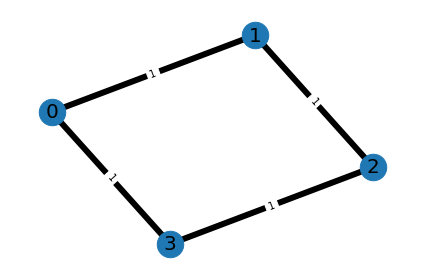

In [26]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()

G.add_edge(0, 1, weight=1)
G.add_edge(1, 2, weight=1)
G.add_edge(2, 3, weight=1)
G.add_edge(3, 0, weight=1)


elarge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] > 0.5]
esmall = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] <= 0.5]

pos = nx.spring_layout(G, seed=7)  # positions for all nodes - seed for reproducibility

# nodes
nx.draw_networkx_nodes(G, pos, node_size=700)

# edges
nx.draw_networkx_edges(G, pos, edgelist=elarge, width=6)
nx.draw_networkx_edges(
    G, pos, edgelist=esmall, width=6, alpha=0.5, edge_color="b", style="dashed"
)

# node labels
nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
# edge weight labels
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()